In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

# Computing the likelihood using MEM

In [1]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"
OUTPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_PureEUMLL.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"

# --- LUMINOSITY SETUP ---
LUMI_FB = 500.0      # Integrated luminosity
LUMI_PB = LUMI_FB * 1000.0

# Total expected events in the "true" Baseline dataset
N_obs = CROSS_SECTIONS[BASELINE_MODEL] * LUMI_PB

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
original_len = len(df)

df = df[df["mg_weight"] >= 0].reset_index(drop=True)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()
w_i = df["w_i"].values

print(f"Loaded {original_len} events. Kept {len(df)} events with positive weights.")
print(f"Luminosity: {LUMI_FB} fb^-1  |  Observed Events (Asimov Data): {N_obs:.1f}\n")

# ==========================================
# 3. COMPUTE RAW MATRIX ELEMENT PROBABILITIES
# ==========================================
for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        # Flavor symmetry fix
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        if model == "Zprime":
            sm_col  = f"ME_Born_SM_{model}_{ch}"
            bsm_col = f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col  = f"ME_Born_{model}_{ch}"
            bsm_col = f"ME_Finite_{model}_{ch}"
            
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    # The total Matrix Element (differential cross-section shape)
    df[f"P_Total_{model}"] = p_sm_total + (p_bsm_leading * scale_factor)

# ==========================================
# 4. COMPUTE PURE EUMLL & SIGNIFICANCE
# ==========================================
print("="*60)
print("COMPUTING PURE EXTENDED UNBINNED LIKELIHOOD (NO SYSTEMATICS)")
print("="*60)

epsilon = 1e-300  # Safeguard against log(0)
results = {}

# Compute Baseline EUMLL
p_base = np.clip(df[f"P_Total_{BASELINE_MODEL}"].values, a_min=epsilon, a_max=None)
nu_tot_base = CROSS_SECTIONS[BASELINE_MODEL] * LUMI_PB

# EUMLL Components for Baseline
yield_term_base = -nu_tot_base
shape_term_base = N_obs * np.sum(w_i * np.log(p_base))
ll_base = yield_term_base + shape_term_base

print(f"BASELINE MODEL: {BASELINE_MODEL}")
print(f"  -> Yield Penalty (-nu_tot) : {yield_term_base:.2f}")
print(f"  -> Shape Likelihood        : {shape_term_base:.2f}")
print(f"  -> Total EUMLL             : {ll_base:.2f}")
print("-" * 60)

# Compute Target EUMLLs and Log-Likelihood Ratios
for model in MODELS.keys():
    p_targ = np.clip(df[f"P_Total_{model}"].values, a_min=epsilon, a_max=None)
    nu_tot_targ = CROSS_SECTIONS[model] * LUMI_PB
    
    yield_term_targ = -nu_tot_targ
    shape_term_targ = N_obs * np.sum(w_i * np.log(p_targ))
    ll_targ = yield_term_targ + shape_term_targ
    
    # Delta LL = Target LL - Baseline LL
    # Because Baseline is the Asimov (true) data, Target LL should be lower, making Delta LL negative.
    delta_ll = ll_targ - ll_base
    
    if delta_ll < 0:
        sig = np.sqrt(-2.0 * delta_ll)
    else:
        sig = 0.0
        
    print(f"TARGET MODEL: {model} [y_dm={Y_DM_CONFIG[model]['y_dm']}]")
    print(f"  -> Expected Yield          : {nu_tot_targ:.1f} events")
    print(f"  -> Yield Penalty (-nu_tot) : {yield_term_targ:.2f}")
    print(f"  -> Shape Likelihood        : {shape_term_targ:.2f}")
    print(f"  -> Total EUMLL             : {ll_targ:.2f}")
    print(f"  -> Delta EUMLL             : {delta_ll:+.2f}")
    print(f"  -> Asimov Significance     : {sig:.2f} sigma")
    print("-" * 60)

# ==========================================
# 5. SAVE RESULTS
# ==========================================
#df.to_csv(OUTPUT_CSV, index=False, compression='infer')
print(f"\nSaved pure EUMLL likelihoods to: {OUTPUT_CSV}")

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events. Kept 3155491 events with positive weights.
Luminosity: 500.0 fb^-1  |  Observed Events (Asimov Data): 630629.5

COMPUTING PURE EXTENDED UNBINNED LIKELIHOOD (NO SYSTEMATICS)
BASELINE MODEL: Scalar
  -> Yield Penalty (-nu_tot) : -630629.50
  -> Shape Likelihood        : 2254862.04
  -> Total EUMLL             : 1624232.54
------------------------------------------------------------
TARGET MODEL: VLF [y_dm=2.715766]
  -> Expected Yield          : 629902.0 events
  -> Yield Penalty (-nu_tot) : -629901.95
  -> Shape Likelihood        : 2253190.56
  -> Total EUMLL             : 1623288.61
  -> Delta EUMLL             : -943.93
  -> Asimov Significance     : 43.45 sigma
------------------------------------------------------------
TARGET MODEL: Scalar [y_dm=4.430268]
  -> Expected Yield          : 630629.5 events
  -> Yield Penalty (-nu_tot) : -630629.50
  -> Shape Likelihood       

# Including Systematics

In [4]:
import pandas as pd
import numpy as np
import glob
import gc
import sys

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz"
OUTPUT_SUMMARY_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_Profiled_Extended_Summary.csv"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P2_uux_ttx", "P3_ddx_ttx", "P0_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]

# Scan Grids
SYS_ERRORS = [0.0, 0.02, 0.05, 0.1, 0.3]             
LUMI_FB_SCAN = [100.0, 300.0, 500.0, 1000.0, 3000.0] 

# ==========================================
# 2. LOAD & FILTER DATA (GLOB)
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)
del dataframes
gc.collect()

# Filter positive weights
df = df[df["mg_weight"] >= 0].reset_index(drop=True)

# Normalized MC Weights: sum to 1
df["omega_mc"] = df["mg_weight"] / df["mg_weight"].sum()
print(f"Kept {len(df)} physical events.")

# ==========================================
# 3. PRECOMPUTE BASE PROBABILITIES
# ==========================================
print("Precomputing Base Matrix Elements...")

for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        # ---------------------------------------------------------
        # FLAVOR SYMMETRY FIX WITH COMPONENT-WISE CLIPPING
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (
                np.clip(df["w_uux"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ddx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ccx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ssx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_bbx"], a_min=0.0, a_max=None)
            )
        else:
            # Clip the single channel flux
            flux = np.clip(df[f"w_{parton_pair}"], a_min=0.0, a_max=None)
            
        # Select the correct column names
        if model == "Zprime":
            if ch == "P2_uux_ttx" or ch == "P3_ddx_ttx":
                sm_col  = "ME_Born_Scalar_P0_uux_ttx" 
            else:
                sm_col  = "ME_Born_Scalar_P2_gg_ttx"
            bsm_col = f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col  = f"ME_Born_{model}_{ch}"
            bsm_col = f"ME_Finite_{model}_{ch}"
            
        # Compute probabilities
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    p_model_total = p_sm_total + (scale_factor * p_bsm_leading)
    
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_Leading_{model}"] = p_bsm_leading
    df[f"P_Total_{model}"] = p_model_total

# ==========================================
# 4. EXTENDED LIKELIHOOD COMPUTATION
# ==========================================
summary_results = []
eps_safeguard = 1e-300

print("\nStarting multi-dimensional scan (Epsilon x Luminosity)...")

for eps in SYS_ERRORS:
    for lumi_fb in LUMI_FB_SCAN:
        lumi_pb = lumi_fb * 1000.0
        
        # Expected total yield for the baseline Asimov dataset
        N_obs = sigma_baseline * lumi_pb
        
        # Effective expected yield represented by each MC phase-space point (w_i)
        w_i = N_obs * df["omega_mc"]
        
        nll_totals = {}
        mean_thetas = {}
        
        for model in MODELS.keys():
            y_dm = Y_DM_CONFIG[model]["y_dm"]
            scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
            
            S_i = df[f"P_SM_{model}"]
            B_i = df[f"P_BSM_Leading_{model}"] * scale_factor
            
            if eps == 0.0:
                theta_i = np.zeros(len(df))
            else:
                # Local Yield Ratio R_i
                denominator = np.clip(lumi_pb * (S_i + B_i), a_min=1e-300, a_max=None)
                R_i = w_i / denominator
                
                # Analytical optimal theta (Event-by-event)
                term1 = (S_i + B_i)**2
                term2 = 4 * (S_i**2) * (eps**2) * lumi_pb * (S_i + B_i) * (R_i - 1.0)
                
                inner_sqrt = np.maximum(term1 + term2, 0.0)
                
                A_coef = S_i * eps
                theta_i = np.where(A_coef > 1e-12, (-(S_i + B_i) + np.sqrt(inner_sqrt)) / (2 * A_coef), 0.0)
            
            # Deformed differential cross-section
            p_prof = S_i * (1 + eps * theta_i) + B_i
            p_safe = np.clip(p_prof, a_min=eps_safeguard, a_max=None)
            
            # Corrected Negative Log-Likelihood Components
            rate_nll = lumi_pb * CROSS_SECTIONS[model]
            shape_nll = -np.sum(w_i * np.log(p_safe))
            penalty_nll = 0.5 * np.sum(theta_i**2)
            
            nll_totals[model] = rate_nll + shape_nll + penalty_nll
            mean_thetas[model] = np.mean(theta_i)

        # Extract Significance
        for model in MODELS.keys():
            delta_nll = nll_totals[model] - nll_totals[BASELINE_MODEL]
            q = 2 * delta_nll
            sig = np.sqrt(q) if q > 0 else 0.0
            
            summary_results.append({
                "Model": model,
                "Luminosity_fb": lumi_fb,
                "Epsilon": eps,
                "Mean_Theta": mean_thetas[model],
                "Delta_NLL": delta_nll,
                "Significance": sig
            })

# ==========================================
# 5. PRINT SUMMARY & SAVE
# ==========================================
df_summary = pd.DataFrame(summary_results)

print("\n" + "="*70)
print("ASIMOV SIGNIFICANCE (Z-SCORE) SCAN")
print("="*70)

for lumi in LUMI_FB_SCAN:
    print(f"\n--- LUMINOSITY: {lumi} fb^-1 ---")
    df_lumi = df_summary[df_summary["Luminosity_fb"] == lumi]
    pivot_sig = df_lumi.pivot(index="Model", columns="Epsilon", values="Significance")
    print(pivot_sig.to_string(float_format="%.2f"))

print("\n" + "="*70)
print("MEAN THETA VS. SYSTEMATIC ERROR")
print("="*70)

for lumi in LUMI_FB_SCAN:
    print(f"\n--- LUMINOSITY: {lumi} fb^-1 ---")
    df_lumi = df_summary[df_summary["Luminosity_fb"] == lumi]
    pivot_theta = df_lumi.pivot(index="Model", columns="Epsilon", values="Mean_Theta")
    print(pivot_theta.to_string(float_format="%+.4e"))

print("\n" + "="*70)
#df_summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
print(f"Saved macroscopic parameter scan summary to: {OUTPUT_SUMMARY_CSV}")

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz
Found 3 files. Loading and concatenating...
Kept 11910996 physical events.
Precomputing Base Matrix Elements...

Starting multi-dimensional scan (Epsilon x Luminosity)...

ASIMOV SIGNIFICANCE (Z-SCORE) SCAN

--- LUMINOSITY: 100.0 fb^-1 ---
Epsilon  0.00  0.02  0.05  0.10  0.30
Model                                
Scalar   0.00  0.00  0.00  0.00  0.00
VLF      1.89  0.00  0.00  0.00  0.00
Zprime  24.71  0.00  0.00  0.00  0.00

--- LUMINOSITY: 300.0 fb^-1 ---
Epsilon  0.00  0.02  0.05  0.10  0.30
Model                                
Scalar   0.00  0.00  0.00  0.00  0.00
VLF      3.27  0.00  0.00  0.00  0.00
Zprime  42.80  0.00  0.00  0.00  0.00

--- LUMINOSITY: 500.0 fb^-1 ---
Epsilon  0.00  0.02  0.05  0.10  0.30
Model                                
Scalar   0.00  0.00  0.00  0.00  0.00
VLF      4.22  0.00  0.00  0.00  0.00
Zprime  55.25  0.00  0.00  0.00  0.00

--- LUMINOSI

In [2]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.478203e-03
  -> Total Log-Likelihood    : -932.20
  -> Asimov Significance     : 43.18 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.749084e-03
  -> Total Log-Likelihood    : -1733.65
  -> Asimov Significance     : 58.88 sigma
------------------------------------------------------------


In [10]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
INPUT_CSV  = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
LUMI_FB = 500.0 
LUMI_PB = LUMI_FB * 1000.0 
EPSILON = 1e-300

print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
df = df[df["mg_weight"] >= 0].reset_index(drop=True)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

if "sqrt_s_hat" not in df.columns:
    df["sqrt_s_hat"] = np.sqrt(df["s_hat"])


# ==========================================
# 2. RAW PROBABILITIES & SYSTEMATICS
# ==========================================

# -- Option 1: Scale-dependent shape error (from invariant mass) --
x_val = np.minimum(df["sqrt_s_hat"].values, 2750.0)
df["sys_shape"] = ((1.43e-06 * (x_val**2)) + (6.18e-03 * x_val) + 4.81) / 100.0

# -- Option 2: Flat systematic error (e.g., 10%) --
df["sys_flat"] = 0.1 

# --- SWITCH SYSTEMATIC ERROR HERE ---
ACTIVE_SYS = "sys_shape"  # Change to "sys_flat" to use the constant 10% error
deltas = df[ACTIVE_SYS].values

print(f"Applying systematic error: {ACTIVE_SYS}")

for model, channels in MODELS.items():
    scale_factor = Y_DM_CONFIG[model]["y_dm"] ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"])
        else:
            flux = df[f"w_{parton_pair}"]
            
        if model == "Zprime":
            p_sm_total += flux * df[f"ME_Born_SM_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Born_NP_{model}_{ch}"]
        else:
            p_sm_total += flux * df[f"ME_Born_{model}_{ch}"]
            p_bsm_leading += flux * df[f"ME_Finite_{model}_{ch}"]
            
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_{model}"] = p_bsm_leading * scale_factor

# ==========================================
# 3. EXACT EVENT-BY-EVENT PROFILING
# ==========================================
def profile_events_analytically(p_sm, p_bsm, sys_array):
    """
    Computes the exact event-by-event optimal nuisance parameters (theta_i) 
    using the analytical quadratic solution.
    """
    A = p_sm * sys_array
    B = p_sm + p_bsm
    
    # Safe division mapping to avoid divide-by-zero where A is 0
    theta_i = np.where(
        A > 1e-12, 
        (-B + np.sqrt(B**2 + 4 * A**2)) / (2 * A), 
        0.0
    )
    
    p_prof = B + (A * theta_i)
    
    # The penalty is strictly the squared shift (we apply the weights in Step 4)
    raw_penalty = 0.5 * (theta_i**2)
    
    return np.clip(p_prof, EPSILON, None), raw_penalty, theta_i

# ==========================================
# 4. COMPUTE JOINT LLR
# ==========================================
print("\n" + "="*60)
print("COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR")
print("="*60)

sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_EVENTS_BASE = sigma_baseline * LUMI_PB
w_i = df["w_i"].values

# FIXED: Correctly assign the full BSM component to the Baseline Model
p_sm_base = df[f"P_SM_{BASELINE_MODEL}"].values
p_bsm_base = df[f"P_BSM_{BASELINE_MODEL}"].values  

p_prof_base, raw_penalty_base, thetas_base = profile_events_analytically(p_sm_base, p_bsm_base, deltas)

# Normalize baseline cross-section dynamically based on the shifted weights
sigma_prof_base = sigma_baseline * np.sum(w_i * (p_prof_base / np.clip(p_sm_base + p_bsm_base, EPSILON, None)))
log_p_base = np.log(p_prof_base / sigma_prof_base)

# FIXED: Multiply the raw penalty by the expected physical event yield (N * w_i)
weighted_penalty_base = N_EVENTS_BASE * w_i * raw_penalty_base
nll_base_total = -np.sum(N_EVENTS_BASE * w_i * log_p_base) + np.sum(weighted_penalty_base)

for model in MODELS.keys():
    if model == BASELINE_MODEL:
        # We can still print the baseline vs baseline validation check
        print(f"Model: {model} [BASELINE]")
        print(f"  -> Profiled Joint LLR       : 0.00")
        print(f"  -> Avg Baseline Nuisance    : {np.mean(thetas_base):+.5f} sigma")
        print("-" * 60)
        continue
        
    p_sm_target = df[f"P_SM_{model}"].values
    p_bsm_target = df[f"P_BSM_{model}"].values
    sigma_target = CROSS_SECTIONS[model]
    
    # Profile the Target Model
    p_prof_target, raw_penalty_target, thetas_target = profile_events_analytically(p_sm_target, p_bsm_target, deltas)
    
    # Normalize target cross-section dynamically
    sigma_prof_target = sigma_target * np.sum(w_i * (p_prof_target / np.clip(p_sm_target + p_bsm_target, EPSILON, None)))
    log_p_target = np.log(p_prof_target / sigma_prof_target)
    
    # FIXED: Multiply the raw penalty by the expected physical event yield
    weighted_penalty_target = N_EVENTS_BASE * w_i * raw_penalty_target
    nll_target_total = -np.sum(N_EVENTS_BASE * w_i * log_p_target) + np.sum(weighted_penalty_target)
    
    # Profiled LLR
    joint_llr = -(nll_target_total - nll_base_total)
    significance = np.sqrt(-2 * joint_llr) if joint_llr < 0 else 0.0
    
    print(f"Model: {model}")
    print(f"  -> Profiled Joint LLR       : {joint_llr:.2f}")
    print(f"  -> Avg Target Nuisance      : {np.mean(thetas_target):+.5f} sigma")
    print(f"  -> Profiled Significance    : {significance:.2f} sigma")
    print("-" * 60)

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Applying systematic error: sys_shape

COMPUTING EVENT-BY-EVENT PROFILED JOINT LLR
Model: VLF
  -> Profiled Joint LLR       : -995.23
  -> Avg Target Nuisance      : +0.19807 sigma
  -> Profiled Significance    : 44.61 sigma
------------------------------------------------------------
Model: Scalar [BASELINE]
  -> Profiled Joint LLR       : 0.00
  -> Avg Baseline Nuisance    : +0.19733 sigma
------------------------------------------------------------
Model: Zprime
  -> Profiled Joint LLR       : -1864.18
  -> Avg Target Nuisance      : +0.19880 sigma
  -> Profiled Significance    : 61.06 sigma
------------------------------------------------------------


In [ ]:
6

In [36]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():
    
    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.496146e-03
  -> Total Log-Likelihood    : -943.51
  -> Asimov Significance     : 43.44 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.786289e-03
  -> Total Log-Likelihood    : -1757.12
  -> Asimov Significance     : 59.28 sigma
------------------------------------------------------------


Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events.
Computing and plotting...


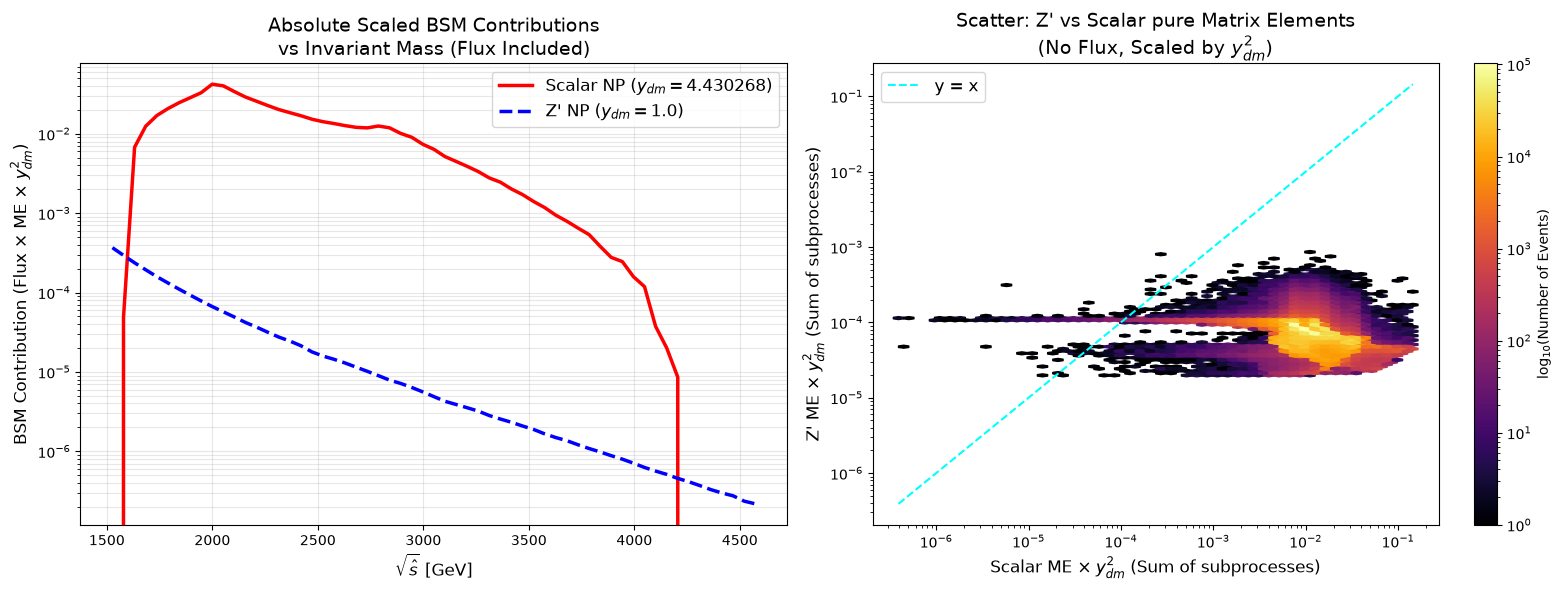

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["w_uux"] * df["ME_Born_NP_Zprime_P3_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_NP_Zprime_P5_ddx_ttx"]) +
    (df["w_gg"]  * df["ME_Born_NP_Zprime_P7_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P3_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P5_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P7_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Z' NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_Zprime_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_Zprime_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_Zprime_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_Zprime_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Z' vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("Z' ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz...
Loaded 3155536 events.
Computing and plotting...


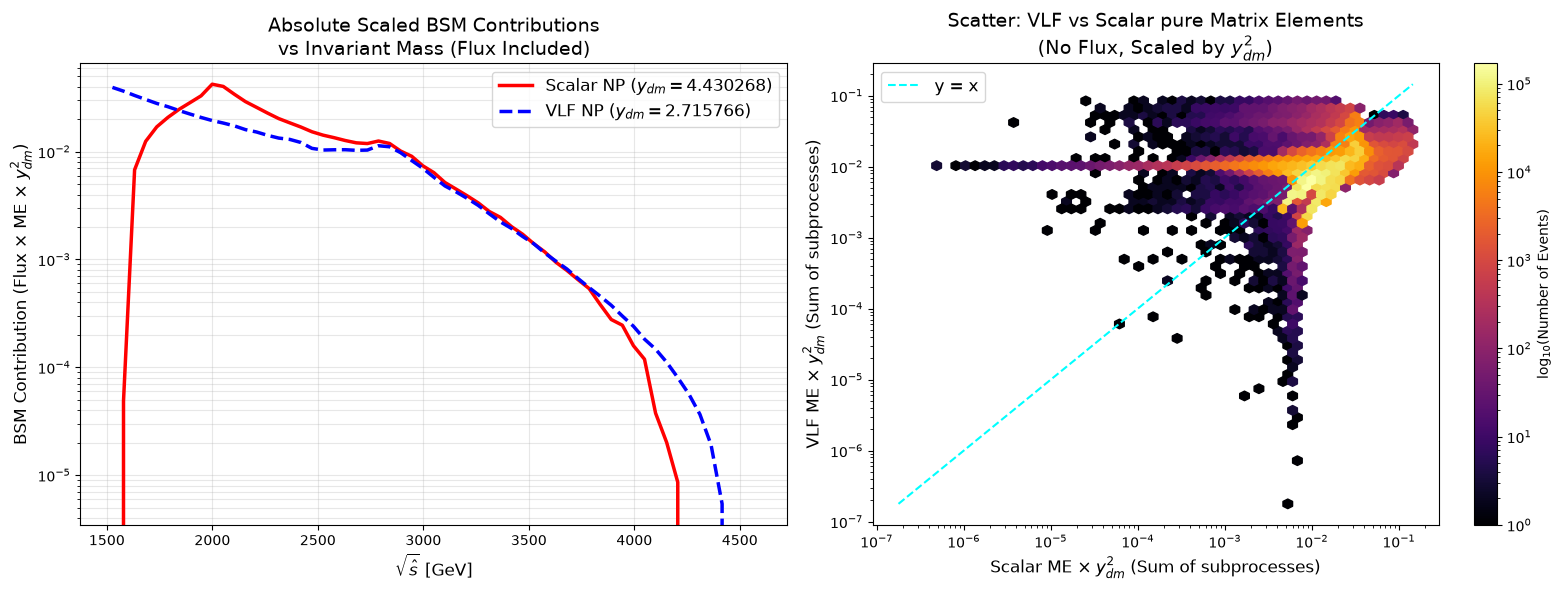

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + 
    df["ME_Finite_VLF_P2_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

In [55]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03,  0.1041545E+03,  0.4176826E+03, -0.1873741E+03],
    [0.5000000E+03, -0.1041545E+03, -0.4176826E+03,  0.1873741E+03]
]

p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,   0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,   0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03, -0.1773983e-306, -0.1736952E+03, -0.4361720E+03],
    [0.5000000E+03,  0.1773983e-306,  0.1736952E+03,  0.4361720E+03]
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            
            # Convert to a NumPy array to check its structural shape
            res_arr = np.array(res)
            
            # DYNAMIC CHECK: Keep the debug print so you can see the raw output structure
            print(f"Debug Raw Array Shape for {os.path.basename(subproc_path)}: {res_arr.shape}")
            
            if res_arr.ndim == 2:
                # [NEW] 2D Patched Wrapper with Split Orders
                
                # Safe Extraction Logic:
                if res_arr.shape[1] > 3:
                    # For P3/P5 (q q~): Array is wide. Extract specific columns.
                    # Column 3 = Pure SM QCD, Column 1 = Pure Z'
                    born_val = float(res_arr[0, 3])
                    finite_val = float(res_arr[0, 1])
                else:
                    # For P7 (gg): Array is narrow. Column 0 is the total sum (which is pure SM QCD)
                    born_val = float(res_arr[0, 0]) 
                    print(res_arr)
                    finite_val = 0
                
                
                pole1_val  = float(res_arr[2, 0])
                pole2_val  = float(res_arr[3, 0])
                
            elif res_arr.ndim == 1 and res_arr.size == 4:
                # 1D Patched Wrapper (Shape: 4)
                born_val   = float(res_arr[0])
                finite_val = float(res_arr[1])
                pole1_val  = float(res_arr[2])
                pole2_val  = float(res_arr[3])
                
            else:
                # Unpatched Original Wrapper (Returns only the Finite term)
                res_list = np.ravel(res_arr)
                born_val   = 0.0
                finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
                pole1_val  = float(res_list[1]) if len(res_list) > 1 else 0.0
                pole2_val  = float(res_list[2]) if len(res_list) > 2 else 0.0
            
            return {
                "Type": "NLO (MadLoop)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": np.ravel(res_arr).tolist()
            }
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

# Initialize LHAPDF to get physical alpha_s at MU_R = 1000 GeV
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            comps = eval_full_me_components(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.4e}",
            "Finite 1-Loop": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.0, -1.77e-307, -173.7, -436.2] GeV

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
Debug Raw Array Shape for P0_uux_ttx: (4,)
Debug Raw Array Shape for P2_gg_ttx: (4,)
Debug Raw Array Shape for P0_uux_ttx: (4,)
Debug Raw Array Shape for P2_gg_ttx: (4,)
Debug Raw Array Shape for P3_uux_ttx: (4, 7)
Debug Raw Array Shape for P5_ddx_ttx: (4, 7)
Debug Raw Array Shape for P7_gg_ttx: (4, 3)
[[ 4.99123668e+00  4.99123668e+00  5.00000000e+02]
 [-4.63847010e-06 -4.09581671e-18 -4.63847010e-06]
 [ 8.70819846e-18 -1.21179334e-35  8.70819846e-18]
 [ 4.39410590e-20  0.00000000e+00  4.39410590e-20]]
 Model    Channel          Type Born (|M0|^2) Finite 1-Loop Single Pole (1/eps) Double Pole (1/eps^2) 